In [34]:
import json
import os
from datetime import timedelta
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (mean_squared_error,
                             r2_score, mean_absolute_error,
                             mean_absolute_percentage_error)
from numpy import sqrt



In [35]:
def error_by_horizon(df_pred, df_ref):
    """
    Calculate error metrics for each horizon in the prediction DataFrame.
    """
    horizons = df_pred.columns
    error_metrics = {}

    for horizon in horizons:
        mse = mean_squared_error(df_ref[horizon], df_pred[horizon])
        r2 = r2_score(df_ref[horizon], df_pred[horizon])
        mae = mean_absolute_error(df_ref[horizon], df_pred[horizon])
        mape = mean_absolute_percentage_error(df_ref[horizon], df_pred[horizon])
        rmse = sqrt(mse)

        error_metrics[horizon] = {
            'MSE': mse,
            'R2': r2,
            'MAE': mae,
            'MAPE': mape,
            'RMSE': rmse
        }

    return pd.DataFrame(error_metrics).T

def general_error(df_pred, df_ref):
    """
    Calculate general error metrics for the entire prediction DataFrame.
    """
    mse = mean_squared_error(df_ref, df_pred)
    r2 = r2_score(df_ref, df_pred)
    mae = mean_absolute_error(df_ref, df_pred)
    mape = mean_absolute_percentage_error(df_ref, df_pred)
    rmse = float(sqrt(mse))

    return {
        'MSE': mse,
        'R2': r2,
        'MAE': mae,
        'MAPE': mape,
        'RMSE': rmse
    }

def general_error_by_file(df_pred_path, df_ref_path):
    """
    Load prediction and reference DataFrames from CSV files and calculate general error metrics.
    """
    df_pred = pd.read_csv(df_pred_path, index_col=0, parse_dates=True)
    df_ref = pd.read_csv(df_ref_path, index_col=0, parse_dates=True)
    #df_pred.drop(columns=['extra'], inplace=True)

    return general_error(df_pred, df_ref)

def error_by_horizon_by_file(exp_path):
    """
    Load prediction and reference DataFrames from CSV files and calculate error metrics.
    """

    df_pred = pd.read_csv(exp_path+"/pred.csv", index_col=0, parse_dates=True)
    df_ref = pd.read_csv(exp_path + "/ref.csv", index_col=0, parse_dates=True)
    #df_pred.drop(columns=['extra'], inplace=True)

    return error_by_horizon(df_pred, df_ref)

def traspose_series_from_df_row(df_pred, row):
    aux_df = df_pred.reset_index()
    transposed_values = aux_df.iloc[row,:].values
    #transposed_values.extend(aux_df.iloc[:,1].values)
    dates = [transposed_values[0] + timedelta(weeks=i) for i in range(len(transposed_values) -1)]
    transposed_series = pd.Series(transposed_values[1:], index=dates, name='val')
    return transposed_series

def plot_all_ref_pred(df_pred, df_ref):

    for i in range(8):
        traspose_series_pred = traspose_series_from_df_row(df_pred, i)
        traspose_series_ref = traspose_series_from_df_row(df_ref, i)

        #plot

        plt.figure(figsize=(10, 5))
        traspose_series_pred.plot(label='Prediction')
        traspose_series_ref.plot(label='Reference')
        plt.title('Prediction vs Reference')
        plt.xlabel('Date')
        plt.ylabel('Value')
        plt.legend()
        plt.grid()
        plt.show()

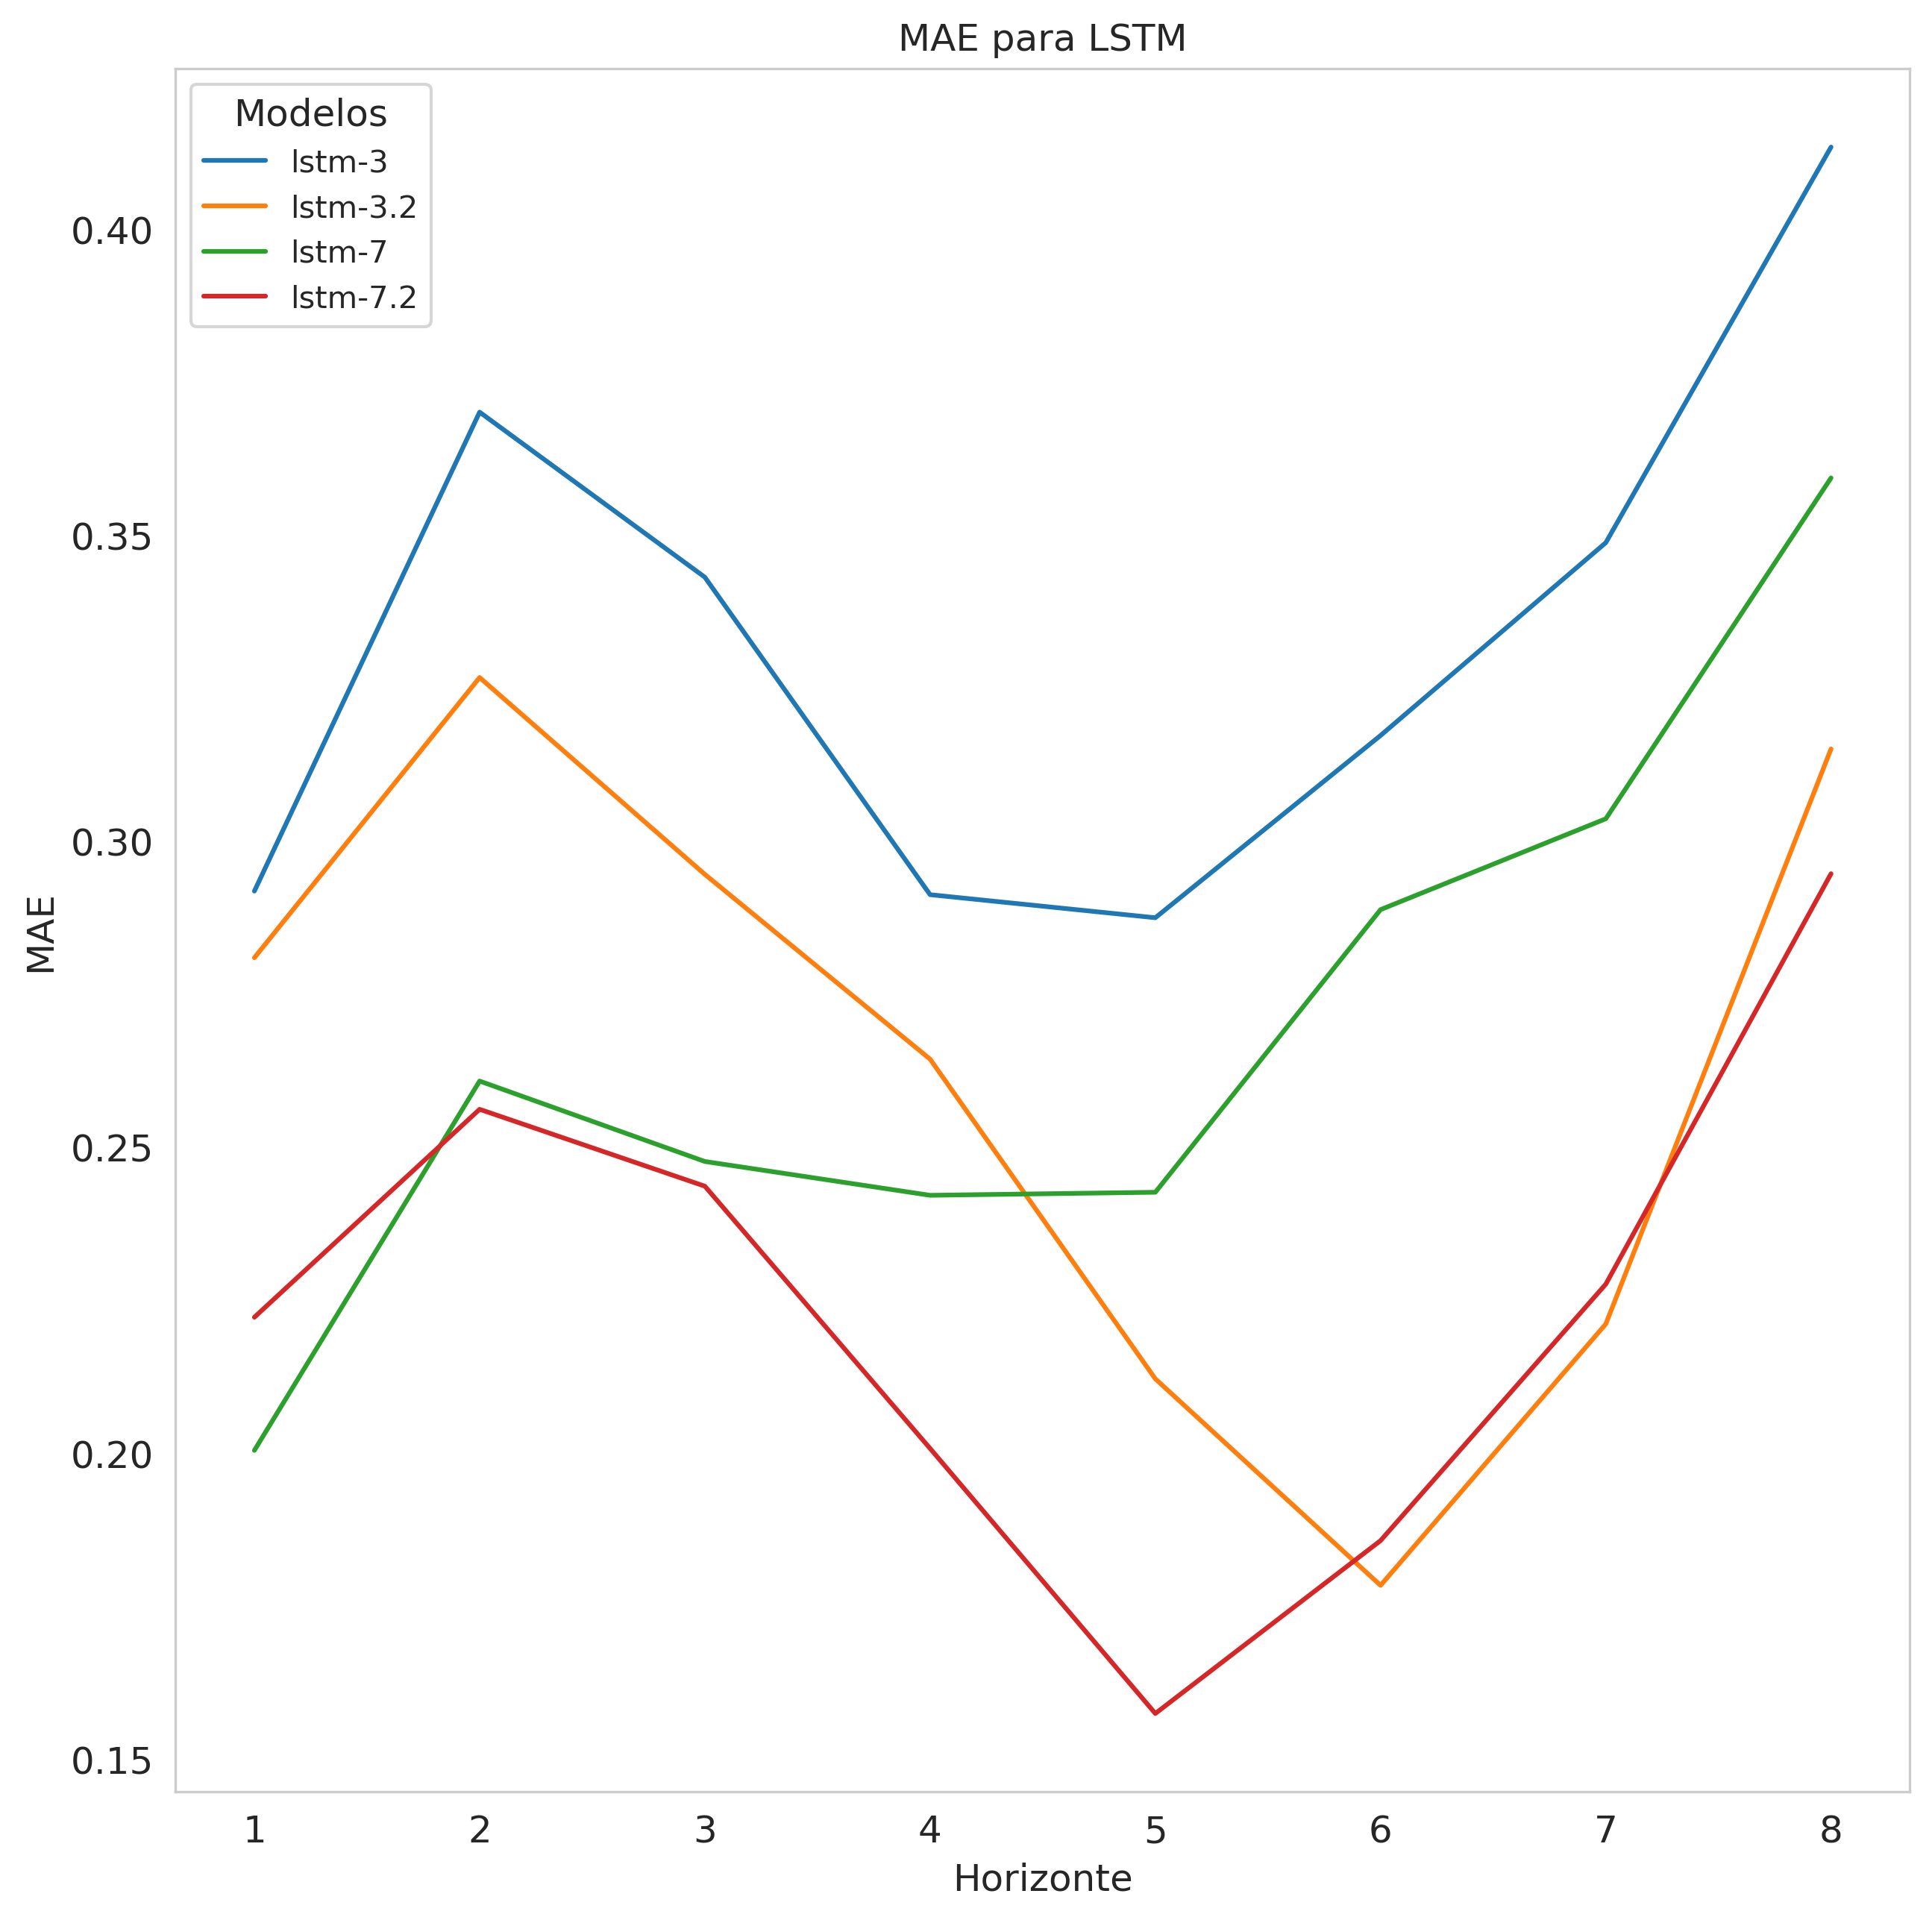

In [36]:

def create_comparison_df(experiment_dir, metric, model):
    folders = []
    for entry in os.listdir(experiment_dir):
        full_path = os.path.join(experiment_dir, entry)
        if os.path.isdir(full_path):
            folders.append(os.path.abspath(full_path))




    configs = []
    for f in folders:
        with open(f+"/config.json", "r") as file:
            configs.append(json.load(file))

    configs_df = pd.DataFrame(configs)

    #error_df = pd.DataFrame(error_list)
    #error_df["id"]  = [f.split("/")[-1] for f in folders]
    # result_df = pd.concat([configs_df, error_df], axis="columns")
    # result_df.set_index("id", inplace=True)



    ids = [config['alias'] for config in configs if config['model'] == model]
    result_df = pd.DataFrame(columns=ids)
    for folder, config in zip(folders, configs):
        if config['model'] != model:
            continue
        error_df = error_by_horizon_by_file(folder)
        result_df[config['alias']] = error_df[metric]

    result_df = result_df[sorted(result_df.columns)]

    return result_df


def plot_comparison_df(experiment_dir, metric, model, override_name=None):

    df = create_comparison_df(experiment_dir, metric, model)
    df.plot(figsize=(10, 10))
    plt.title(f'{metric} para {model if override_name is None else override_name}')
    plt.xlabel('Horizonte')
    plt.ylabel(metric)
    plt.grid()
    plt.legend(title='Modelos')
    plt.show()

plot_comparison_df("../../experiments/exp_2025-07-26", 'MAE', 'simple_lstm_v0', override_name= "LSTM")


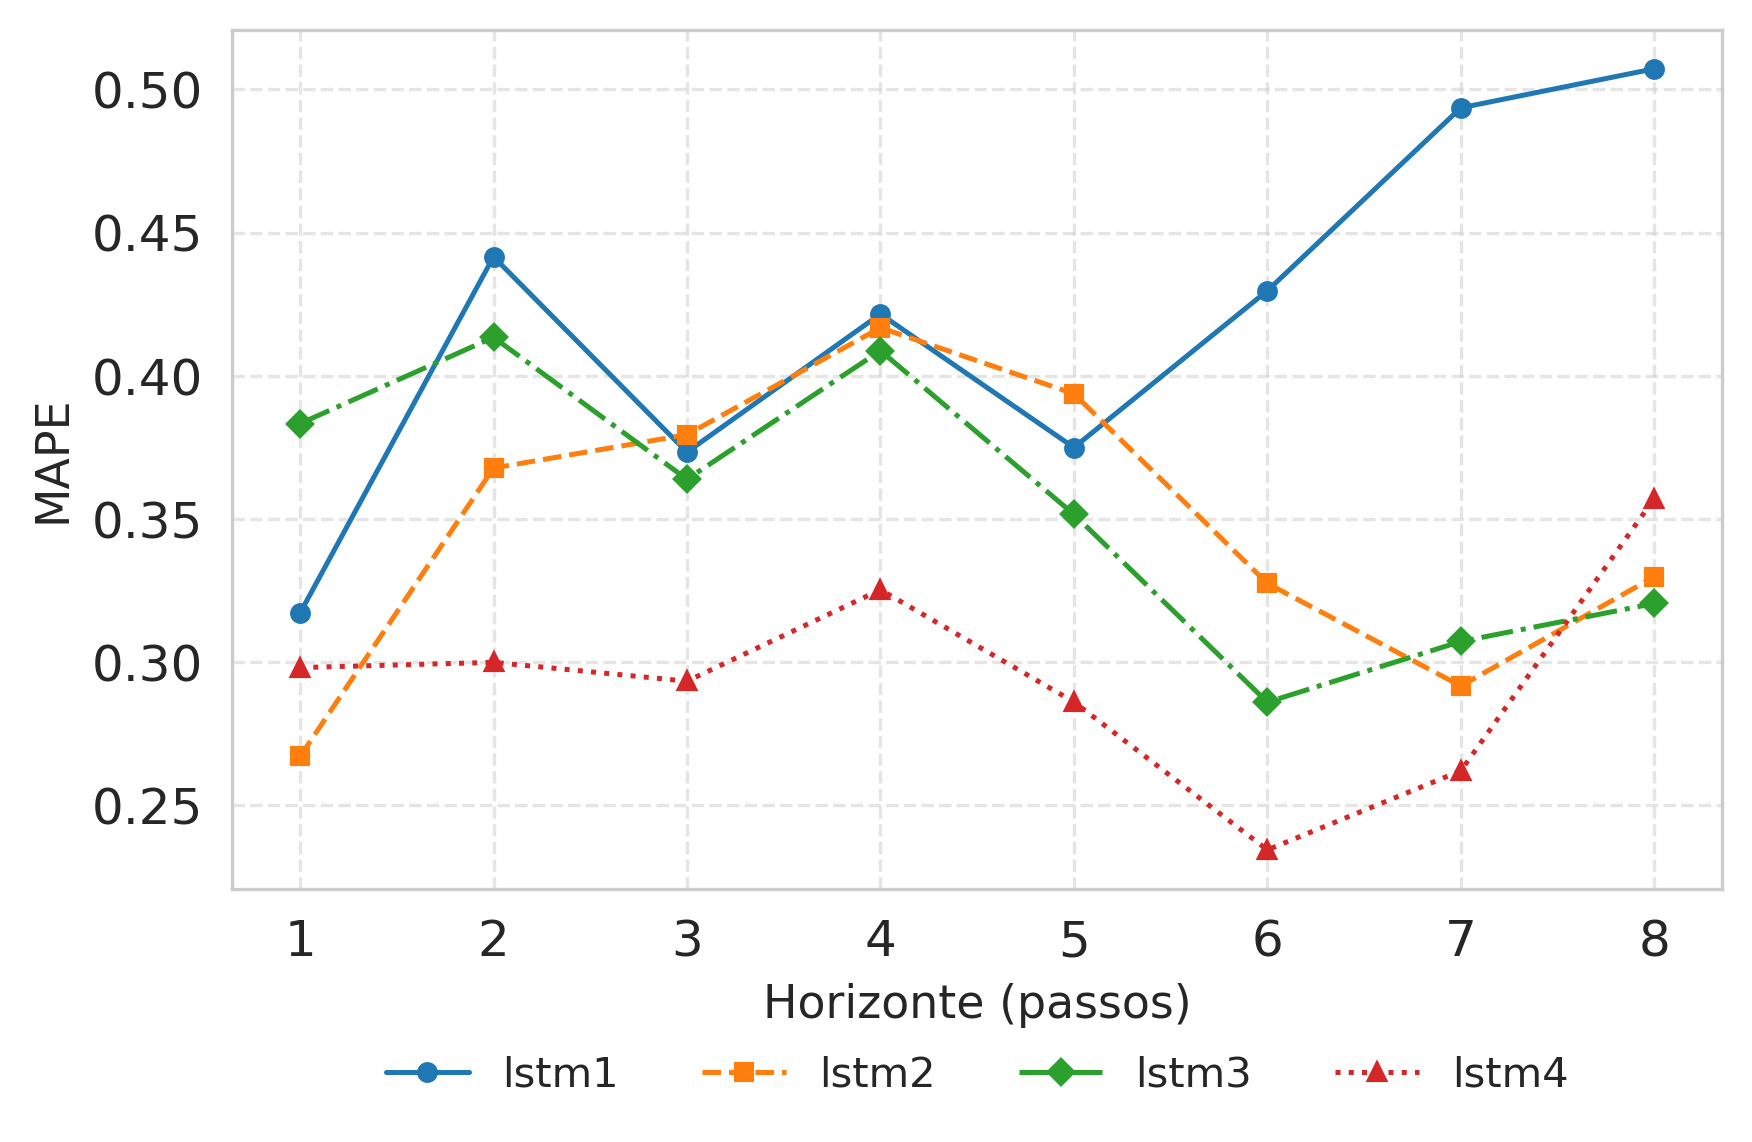

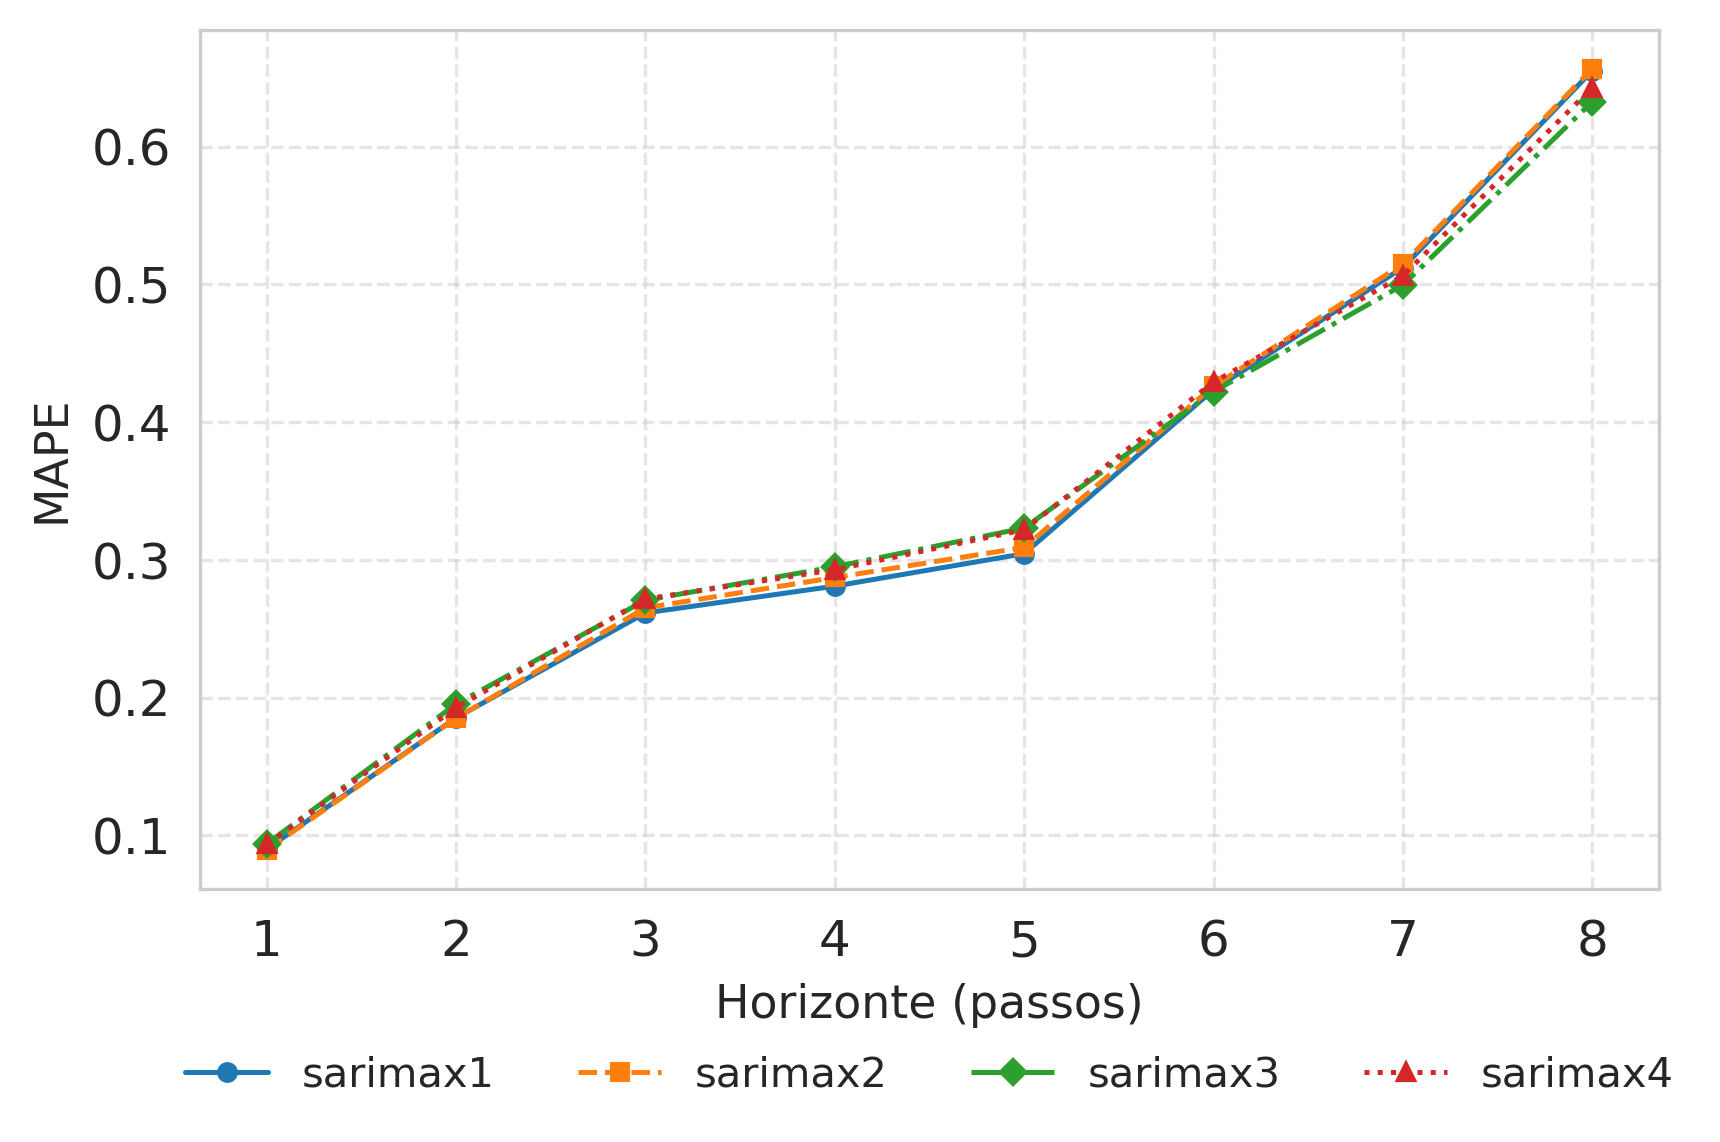

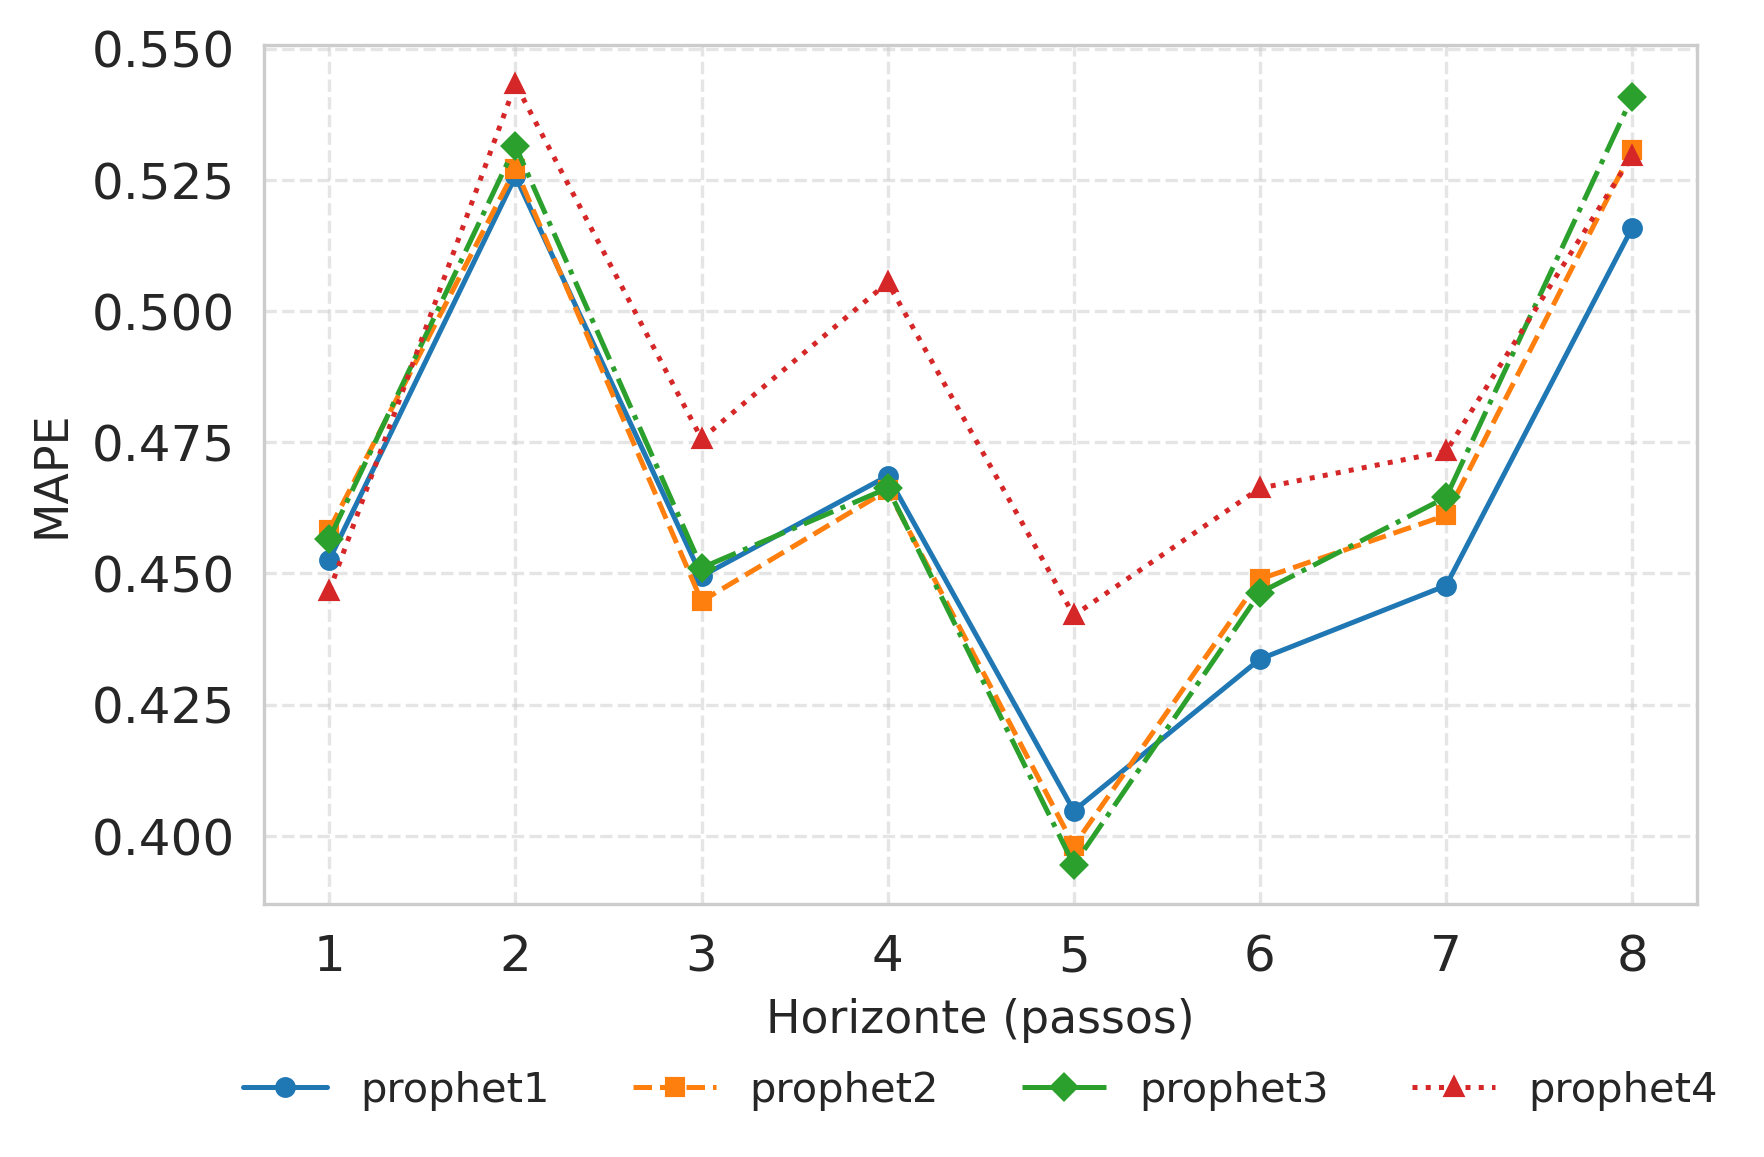

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns

def plot_comparison_df_scientific(experiment_dir, metric, model, override_name=None):
    sns.set_style("whitegrid")
    plt.rcParams.update({
        'font.size': 12,
        'axes.labelsize': 12,
        'axes.titlesize': 12,
        'legend.fontsize': 10,
        'figure.dpi': 300
    })

    df = create_comparison_df(experiment_dir, metric, model)

    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

    styles = ['-', '--', '-.', ':']
    markers = ['o', 's', 'D', '^']
    for i, col in enumerate(df.columns):
        ax.plot(
            df.index, df[col],
            label=col,
            linestyle=styles[i % len(styles)],
            marker=markers[i % len(markers)],
            markersize=4,
            linewidth=1.2
        )

    ax.set_xlabel('Horizonte (passos)', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    if override_name:
        ax.set_title(f'{metric} - {override_name}', fontsize=12, pad=10)

    ax.grid(True, linestyle='--', alpha=0.5)

    # ✅ Legenda abaixo, centralizada, com múltiplas colunas
    ax.legend(
        title='',
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),  # posição abaixo
        ncol=len(df.columns),         # todas as legendas em uma linha
        frameon=False
    )

    plt.tight_layout()
    plt.show()


plot_comparison_df_scientific("../../experiments/exp_2025-07-27", 'MAPE', 'simple_lstm_v0', override_name= None)
plot_comparison_df_scientific("../../experiments/exp_2025-07-27", 'MAPE', 'sarimax', override_name= None)
plot_comparison_df_scientific("../../experiments/exp_2025-07-27", 'MAPE', 'prophet', override_name= None)

MAE


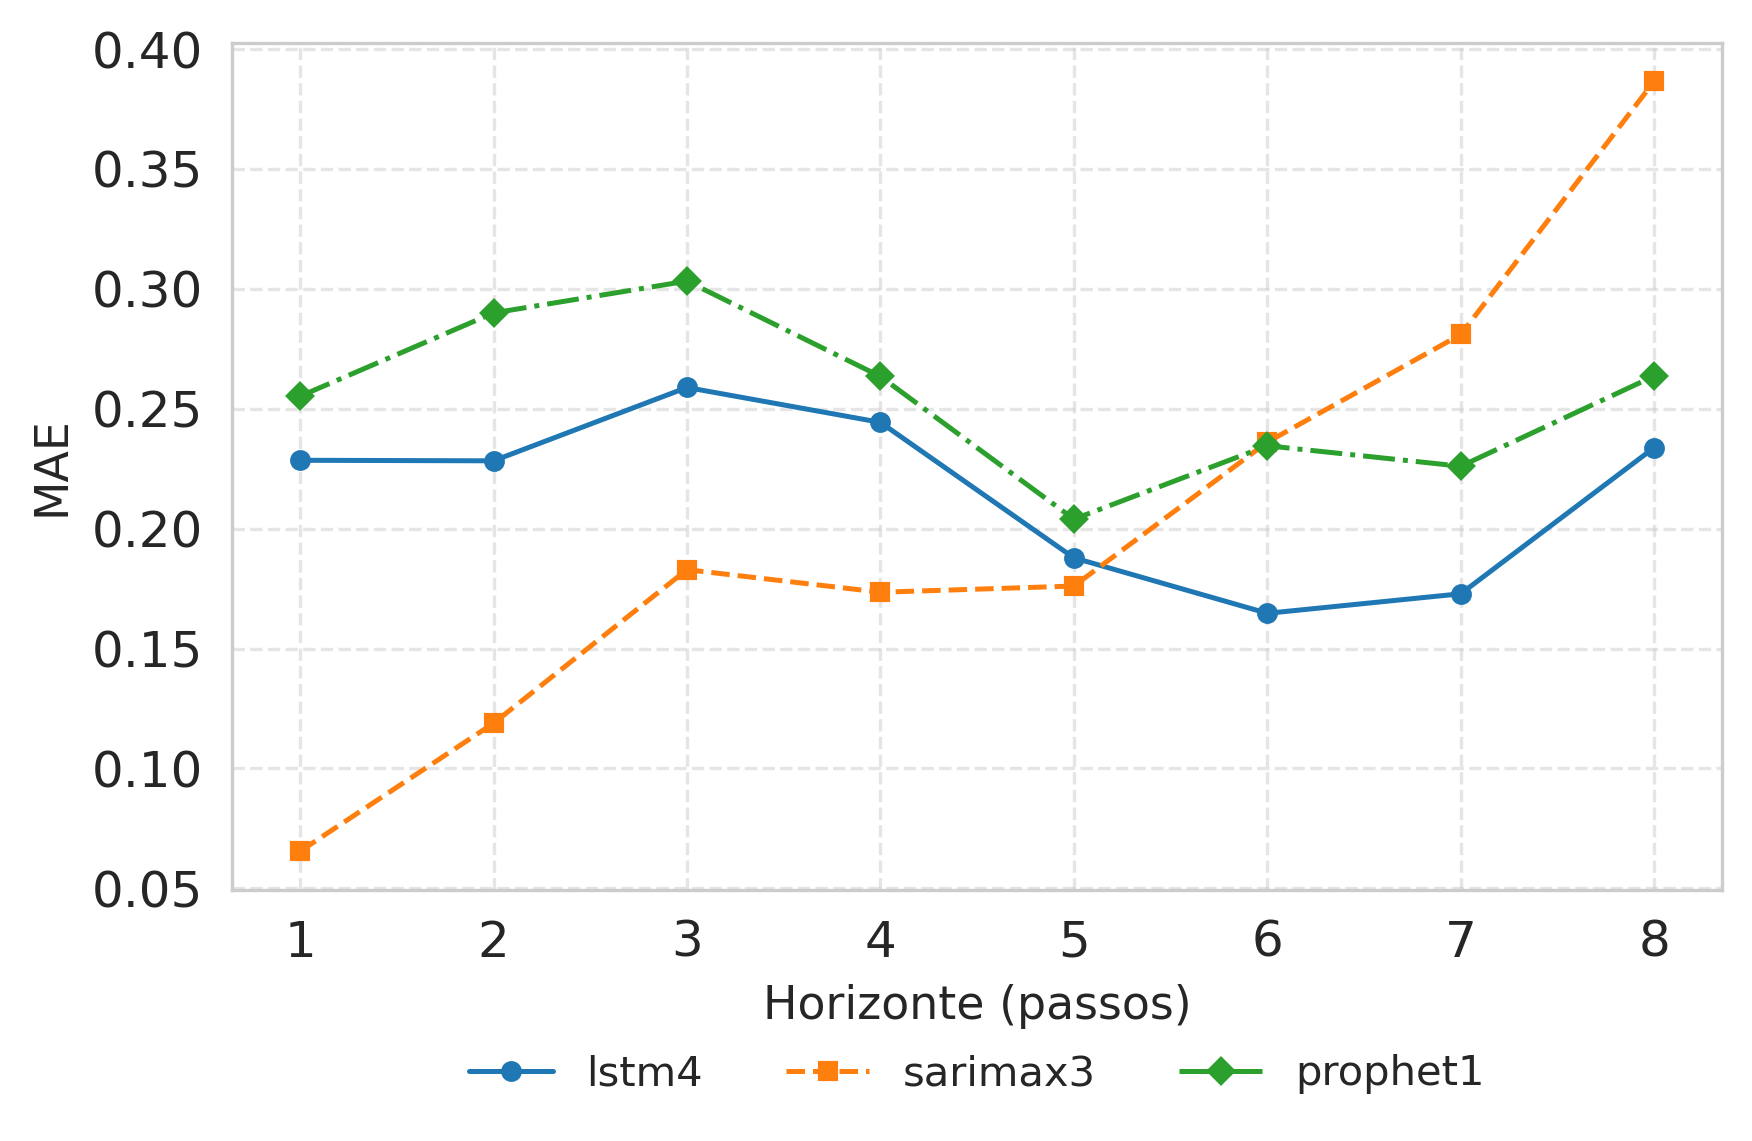

MSE


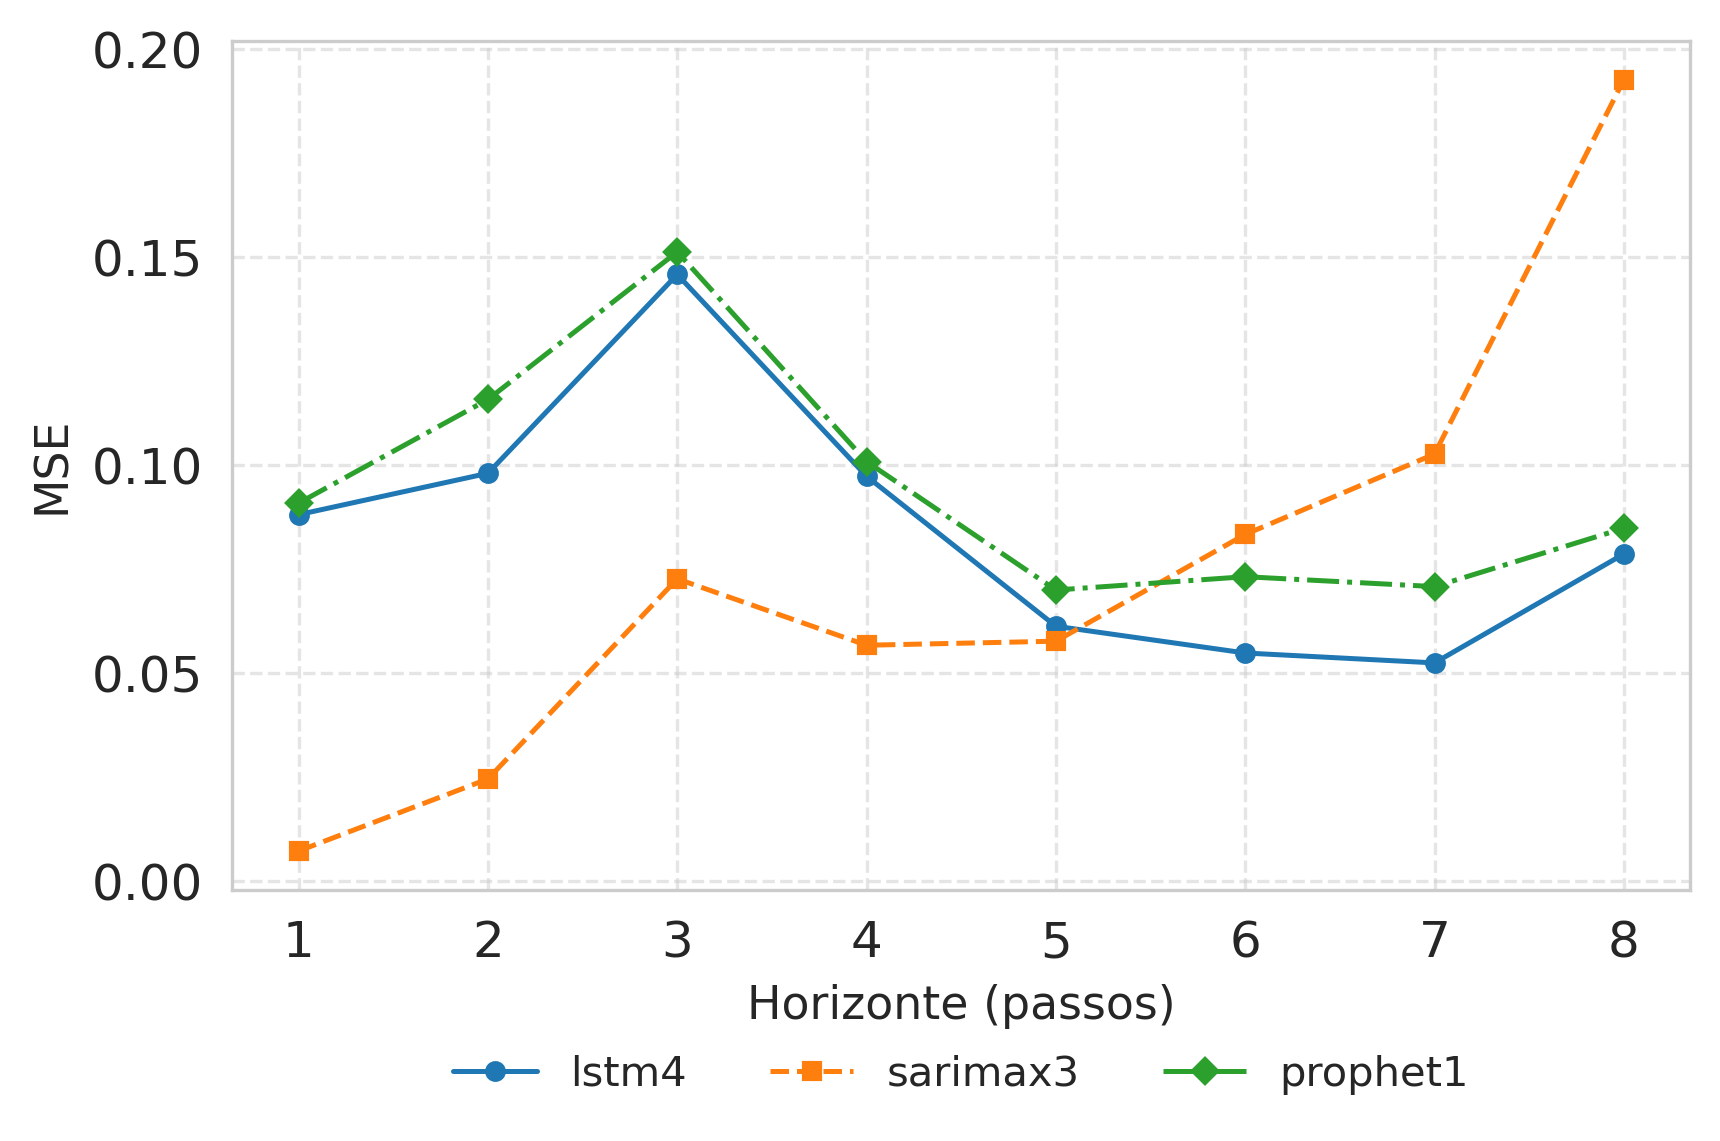

R2


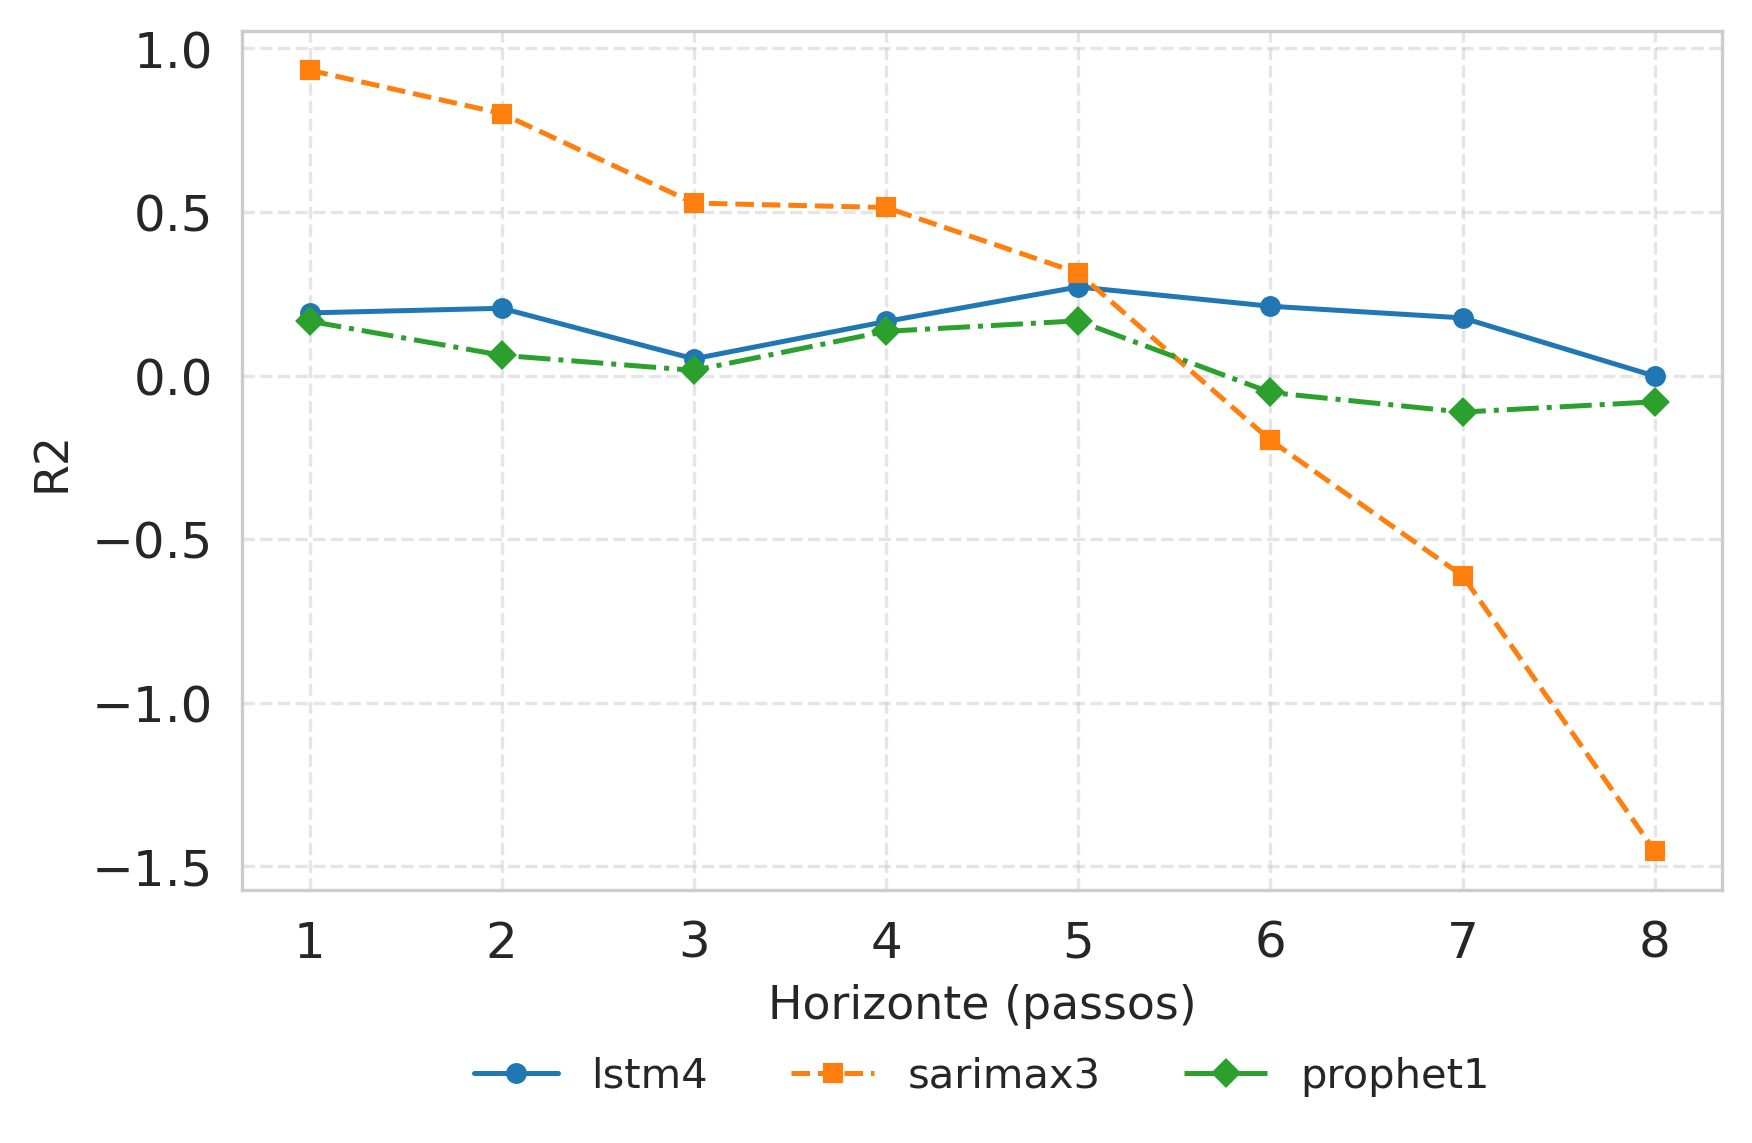

,lstm4,sarimax3,prophet1
1,0.191490,0.933587,0.166063
2,0.205677,0.801075,0.061907
3,0.051166,0.527247,0.015828
4,0.165386,0.513777,0.135216
5,0.270873,0.313686,0.167288
6,0.211884,-0.197759,-0.051754
7,0.176283,-0.612187,-0.111694
8,-0.001589,-1.453464,-0.080273


In [46]:

def compare_best_models(experiment_dir, metric):
    lstm = create_comparison_df(experiment_dir, metric, 'simple_lstm_v0')['lstm4']
    sarimax = create_comparison_df(experiment_dir, metric, 'sarimax')['sarimax3']
    prophet = create_comparison_df(experiment_dir, metric, 'prophet')['prophet1']

    comparison_df = pd.DataFrame([lstm, sarimax, prophet]).transpose()

    sns.set_style("whitegrid")
    plt.rcParams.update({
        'font.size': 12,
        'axes.labelsize': 12,
        'axes.titlesize': 12,
        'legend.fontsize': 10,
        'figure.dpi': 300
    })

    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

    styles = ['-', '--', '-.', ':']
    markers = ['o', 's', 'D', '^']
    for i, col in enumerate(comparison_df.columns):
        ax.plot(
            comparison_df.index, comparison_df[col],
            label=col,
            linestyle=styles[i % len(styles)],
            marker=markers[i % len(markers)],
            markersize=4,
            linewidth=1.2
        )

    ax.set_xlabel('Horizonte (passos)', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    #if override_name:
    #    ax.set_title(f'{metric} - {override_name}', fontsize=12, pad=10)

    ax.grid(True, linestyle='--', alpha=0.5)

    # ✅ Legenda abaixo, centralizada, com múltiplas colunas
    ax.legend(
        title='',
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),  # posição abaixo
        ncol=len(comparison_df.columns),         # todas as legendas em uma linha
        frameon=False
    )

    plt.tight_layout()
    plt.show()

    return comparison_df

print("MAE")
compare_best_models("../../experiments/exp_2025-07-27", 'MAE')
print("MSE")
compare_best_models("../../experiments/exp_2025-07-27", 'MSE')
print("R2")
compare_best_models("../../experiments/exp_2025-07-27", 'R2')

In [7]:
def get_error_df(experiment_dir):
    folders = []
    for entry in os.listdir(experiment_dir):
        full_path = os.path.join(experiment_dir, entry)
        if os.path.isdir(full_path):
            folders.append(os.path.abspath(full_path))

    error_list = [
    general_error_by_file(f + "/pred.csv", f + "/ref.csv")
    for f in folders]


    configs = []
    for f in folders:
        with open(f+"/config.json", "r") as file:
            configs.append(json.load(file))

    configs_df = pd.DataFrame(configs)

    error_df = pd.DataFrame(error_list)
    error_df["id"]  = [f.split("/")[-1] for f in folders]
    result_df = pd.concat([configs_df, error_df], axis="columns")
    result_df.set_index("id", inplace=True)

    return result_df

In [8]:
get_error_df("../../experiments/exp_2025-07-27")

,model,alias,input_file,input_size,output_size,keep_only,result_file,save_path,experiment_group,train_valid_test,columns,model_params,MSE,R2,MAE,MAPE,RMSE
id,,,,,,,,,,,,,,,,,
res_lstm1.json,simple_lstm_v0,lstm1,/home/patrick/Desktop/Projects/time-series-ana...,52,8,None,result.csv,../../saved_models,4,"[230, 72, 100]",[Alface Crespa - Roça],"{'units': 100, 'dropout': 0.2, 'activation': '...",0.101717,-0.031651,0.248672,0.419899,0.318931
res_lstm3.json,simple_lstm_v0,lstm3,/home/patrick/Desktop/Projects/time-series-ana...,52,8,None,result.csv,../../saved_models,4,"[230, 72, 100]","[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4, ...","{'units': 100, 'dropout': 0.2, 'activation': '...",0.090640,0.123719,0.229656,0.354366,0.301065
res_sarimax.gs4.json,sarimax,sarimax4,/home/patrick/Desktop/Projects/time-series-ana...,52,8,None,result.csv,../../saved_models,4,"[230, 72, 100]","[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4, ...","{'pdq': [0, 1, 1], 'PDQM': [0, 0, 0, 52], 'tre...",0.075346,0.093082,0.203662,0.343753,0.274492
res_prophet4.json,prophet,prophet4,/home/patrick/Desktop/Projects/time-series-ana...,52,8,None,result.csv,../../saved_models,4,"[230, 72, 100]","[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4, ...",NaN,0.103686,-0.061305,0.265323,0.485268,0.322003
res_sarimax.gs1.json,sarimax,sarimax1,/home/patrick/Desktop/Projects/time-series-ana...,52,8,None,result.csv,../../saved_models,4,"[230, 72, 100]",[Alface Crespa - Roça],"{'pdq': [0, 1, 1], 'PDQM': [0, 0, 0, 52], 'tre...",0.076496,0.077632,0.202870,0.339105,0.276579
res_sarimax.gs3.json,sarimax,sarimax3,/home/patrick/Desktop/Projects/time-series-ana...,52,8,None,result.csv,../../saved_models,4,"[230, 72, 100]","[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4, ...","{'pdq': [0, 1, 1], 'PDQM': [0, 0, 0, 52], 'tre...",0.074643,0.103245,0.202535,0.341498,0.273208
res_lstm2.json,simple_lstm_v0,lstm2,/home/patrick/Desktop/Projects/time-series-ana...,52,8,None,result.csv,../../saved_models,4,"[230, 72, 100]","[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4]","{'units': 100, 'dropout': 0.2, 'activation': '...",0.088183,0.142844,0.235151,0.346744,0.296957
res_prophet1.json,prophet,prophet1,/home/patrick/Desktop/Projects/time-series-ana...,52,8,None,result.csv,../../saved_models,4,"[230, 72, 100]",[Alface Crespa - Roça],NaN,0.094638,0.037823,0.254984,0.462285,0.307634
res_sarimax.gs2.json,sarimax,sarimax2,/home/patrick/Desktop/Projects/time-series-ana...,52,8,None,result.csv,../../saved_models,4,"[230, 72, 100]","[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4]","{'pdq': [0, 1, 1], 'PDQM': [0, 0, 0, 52], 'tre...",0.077705,0.063273,0.203632,0.341617,0.278756


<Axes: >

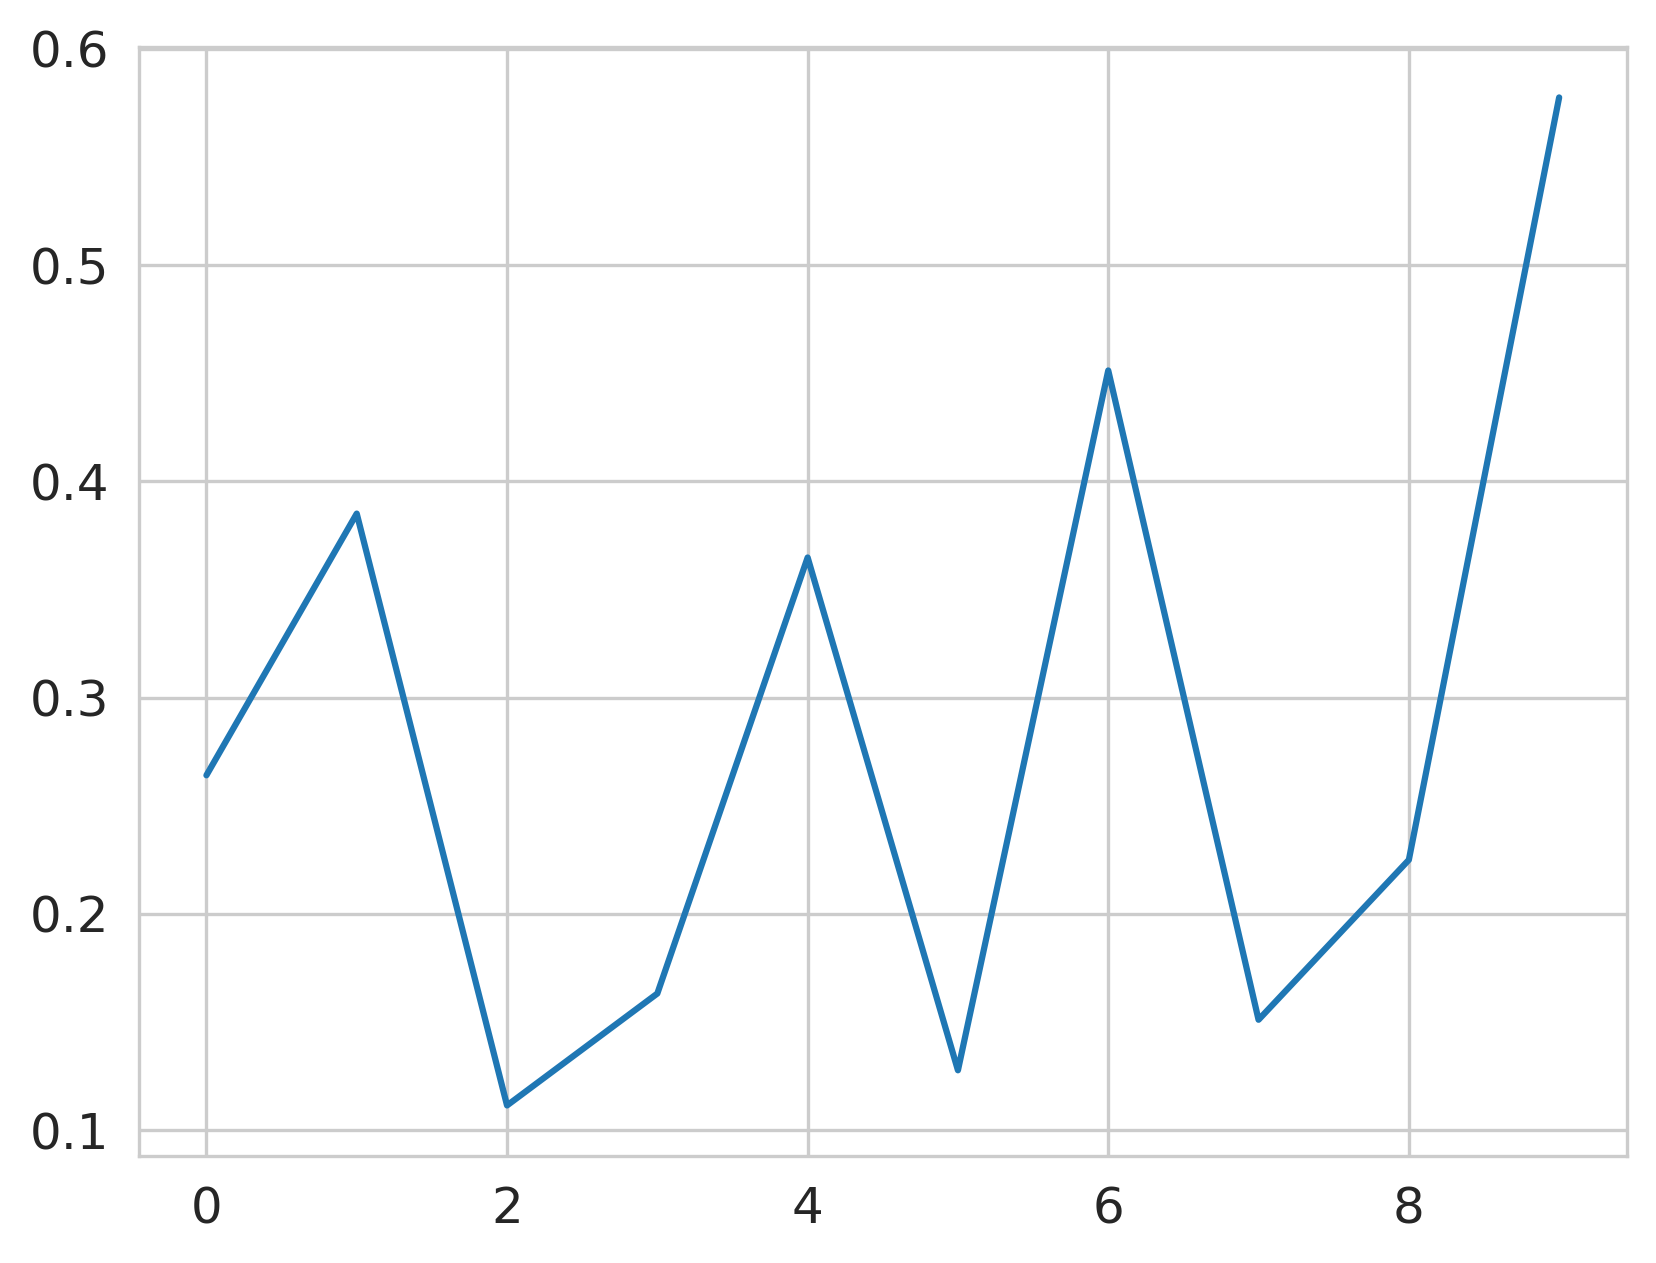

In [53]:
def get_error_by_fold(exp_dir):
    pass

dir_path = "/home/patrick/Desktop/Projects/time-series-analysis/experiments/exp_2025-07-27/res_lstm1.json/"

pred_df = pd.read_csv(dir_path + "pred.csv", index_col=0)
ref_df = pd.read_csv(dir_path + "ref.csv", index_col=0)

errors = []

for i in range(len(ref_df)):
    """
    mse = mean_squared_error(df_ref, df_pred)
    r2 = r2_score(df_ref, df_pred)
    mae = mean_absolute_error(df_ref, df_pred)
    mape = mean_absolute_percentage_error(df_ref, df_pred)
    rmse = float(sqrt(mse))
    """
    errors.append({
        "mse": mean_squared_error(ref_df.iloc[i, :], pred_df.iloc[i, :]),
        "r2": r2_score(ref_df.iloc[i, :], pred_df.iloc[i, :]),
        "rmse": float(sqrt( mean_squared_error(ref_df.iloc[i, :], pred_df.iloc[i, :]))),
        "mae": mean_absolute_error(ref_df.iloc[i, :], pred_df.iloc[i, :]),
        "mape": mean_absolute_percentage_error(ref_df.iloc[i, :], pred_df.iloc[i, :]),
    })

pd.DataFrame(errors, columns=["mse", "r2", "rmse", "mae", "mape"])['rmse'].plot()



array([0.67674524, 0.71851206, 0.64974356, 0.71132624, 0.6767025 ,
       0.6064233 , 0.74285024, 0.61296296])

In [9]:

error_df = create_comparison_df("../../experiments/exp_2025-07-26")
error_df['num_vars'] = error_df['columns'].apply(lambda x: len(x))
error_df[[ 'alias', 'columns', 'MSE', 'R2', 'MAE', 'MAPE', 'RMSE']].sort_values(by='RMSE')

TypeError: create_comparison_df() missing 2 required positional arguments: 'metric' and 'model'

---


In [16]:
error_by_horizon_by_file("../../experiments/exp_2025-07-05/res_config1.json")

,MSE,R2,MAE,MAPE,RMSE
1,0.101352,0.178355,0.273831,0.492004,0.318358
2,0.141539,0.078572,0.291898,0.427137,0.376216
3,0.094355,0.190444,0.255935,0.451853,0.307172
4,0.063573,0.243069,0.195601,0.387453,0.252136
5,0.065929,0.051926,0.223718,0.411673,0.256766
6,0.064697,-0.016511,0.219183,0.431192,0.254357
7,0.080798,-0.029577,0.257458,0.498784,0.284250
8,0.110335,-0.011517,0.292015,0.535451,0.332168


In [17]:
error_by_horizon_by_file("../../experiments/exp_2025-07-05/res_config3.json")

,MSE,R2,MAE,MAPE,RMSE
1,0.133813,-0.084804,0.261698,0.389801,0.365804
2,0.242095,-0.576057,0.357334,0.512493,0.492031
3,0.186686,-0.601749,0.347291,0.550238,0.432071
4,0.142903,-0.701481,0.310758,0.542887,0.378025
5,0.128380,-0.846150,0.300615,0.532295,0.358302
6,0.106546,-0.674028,0.296826,0.544707,0.326414
7,0.154636,-0.970461,0.345000,0.621628,0.393237
8,0.183343,-0.680828,0.385308,0.698662,0.428186


In [18]:
error_df = create_comparison_df("../../experiments/exp_2025-07-26-2")
error_df['num_vars'] = error_df['columns'].apply(lambda x: len(x))
error_df[[ 'alias', 'columns', 'MSE', 'R2', 'MAE', 'MAPE', 'RMSE']].sort_values(by='RMSE')

,alias,columns,MSE,R2,MAE,MAPE,RMSE
id,,,,,,,
res_config2.json,"sarimax(1,1,0)(0,0,1,56)ct",[Alface Crespa - Roça],0.077277,0.150952,0.204966,0.339269,0.277987
res_config2x.json,"sarimax(1,1,0)(0,0,1,56)ct",[Alface Crespa - Roça],0.088673,-0.085189,0.218841,0.362394,0.297780
res_config2x2.json,"sarimax(1,1,0)(0,0,1,56)ct",[Alface Crespa - Roça],0.120937,-0.421304,0.266777,0.428928,0.347760


In [19]:
error_df = create_comparison_df("../../experiments/exp_2025-07-26-3")
error_df['num_vars'] = error_df['columns'].apply(lambda x: len(x))
error_df[[ 'alias', 'columns', 'MSE', 'R2', 'MAE', 'MAPE', 'RMSE']].sort_values(by='RMSE')

,alias,columns,MSE,R2,MAE,MAPE,RMSE
id,,,,,,,
res_sarimax4x2.2.json,"sarimax(0, 1, 1)(0, 0, 0, 56)ct-2","[Alface Crespa - Roça, PRES_MIN_ANT_max_ra4]",0.073420,0.118531,0.201809,0.338449,0.270961
res_sarimax4.json,"sarimax(0, 1, 1)(0, 0, 0, 56)ct",[Alface Crespa - Roça],0.076266,0.080651,0.202369,0.338685,0.276162
res_sarimax4x2.3shift.diff.json,"sarimax(0, 1, 1)(0, 0, 0, 56)ct-2","[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4_s...",0.076529,0.077953,0.203375,0.338966,0.276638
res_lstm4.json,lstm4,"[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4, ...",0.076704,0.225509,0.217949,0.326762,0.276956
res_sarimax4x2.3shift.json,"sarimax(0, 1, 1)(0, 0, 0, 56)ct-2","[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4_s...",0.076816,0.074160,0.203813,0.339921,0.277156
res_sarimax4x2.json,"sarimax(0, 1, 1)(0, 0, 0, 56)ct-2","[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4]",0.077476,0.065700,0.203220,0.341181,0.278346
res_lstm7.json,lstm7,"[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4, ...",0.081996,0.158380,0.223712,0.342728,0.286349
res_lstm5.json,lstm5,"[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4, ...",0.082115,0.178811,0.209644,0.284048,0.286557
res_lstm3.json,lstm3,"[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4, ...",0.082635,0.204475,0.217162,0.333326,0.287463


In [20]:
error_df = create_comparison_df("../../experiments/exp_2025-07-27")
error_df['num_vars'] = error_df['columns'].apply(lambda x: len(x))
error_df[[ 'alias', 'columns', 'MSE', 'R2', 'MAE', 'MAPE', 'RMSE']].sort_values(by='RMSE')

,alias,columns,MSE,R2,MAE,MAPE,RMSE
id,,,,,,,
res_sarimax.gs3.json,"sarimax(0, 1, 1)(0, 0, 0, 56)ct","[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4, ...",0.074643,0.103245,0.202535,0.341498,0.273208
res_sarimax.gs4.json,"sarimax(0, 1, 1)(0, 0, 0, 56)ct","[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4, ...",0.075346,0.093082,0.203662,0.343753,0.274492
res_sarimax.gs1.json,"sarimax(0, 1, 1)(0, 0, 0, 56)ct",[Alface Crespa - Roça],0.076496,0.077632,0.202870,0.339105,0.276579
res_sarimax.gs2.json,"sarimax(0, 1, 1)(0, 0, 0, 56)ct","[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4]",0.077705,0.063273,0.203632,0.341617,0.278756
res_lstm4.json,lstm4,"[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4, ...",0.084515,0.158896,0.214877,0.294579,0.290715
res_lstm2.json,lstm2,"[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4]",0.088183,0.142844,0.235151,0.346744,0.296957
res_lstm3.json,lstm3,"[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4, ...",0.090640,0.123719,0.229656,0.354366,0.301065
res_prophet1.json,prophet-1,[Alface Crespa - Roça],0.094638,0.037823,0.254984,0.462285,0.307634
res_prophet2.json,prophet-2,"[Alface Crespa - Roça, VENT_VEL_HOR_mean_ra4]",0.099841,-0.018476,0.259080,0.466856,0.315976


In [21]:
df_old = pd.read_csv("/home/patrick/Desktop/Projects/time-series-analysis/processed_data/price_weather_weekly_df-2016-2023.csv", index_col=0, parse_dates=True)
df_new = pd.read_csv("/home/patrick/Desktop/Projects/time-series-analysis/Notebooks/Part 2/price_weather_df.v2.csv", index_col=0, parse_dates=True)

<Axes: xlabel='dt'>

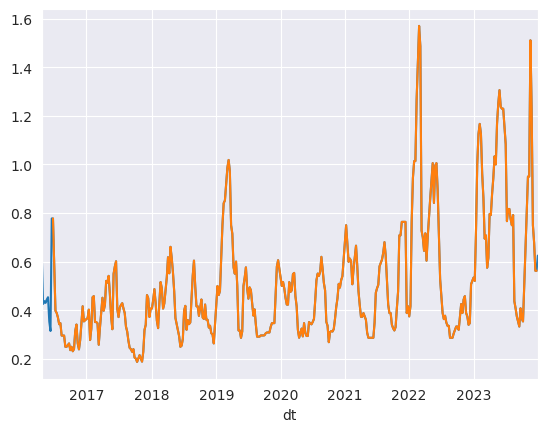

In [22]:
df_old['Alface Crespa - Roça'].plot()
df_new['Alface Crespa - Roça'].plot()


<Axes: xlabel='dt'>

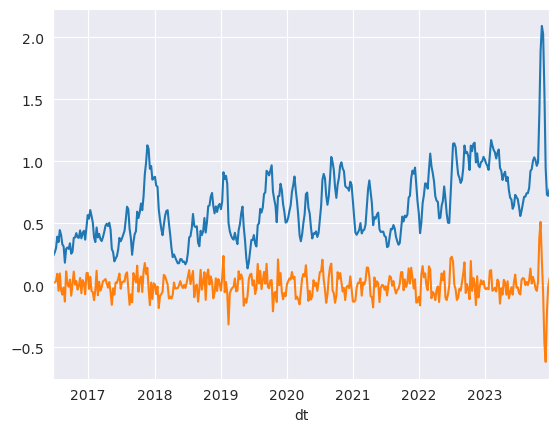

In [23]:
df_new['VENT_VEL_HOR_mean_ra4_shift8'].plot()
df_new['VENT_VEL_HOR_mean_ra4_shift8'].diff(1).plot()

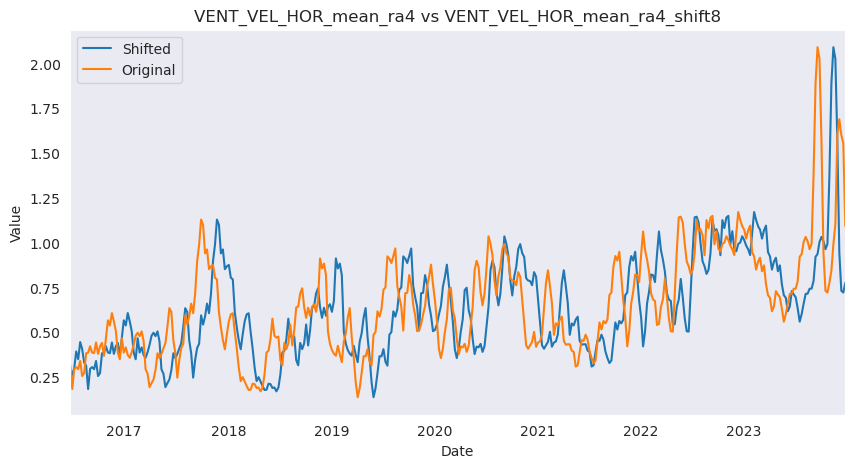

In [24]:

#plot boht in one figure
plt.figure(figsize=(10, 5))
df_new['VENT_VEL_HOR_mean_ra4_shift8'].plot(label='Shifted')
df_new['VENT_VEL_HOR_mean_ra4'].plot(label='Original')
plt.title('VENT_VEL_HOR_mean_ra4 vs VENT_VEL_HOR_mean_ra4_shift8')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()